In [6]:
import numpy as np
import pandas as pd
from astropy import units as u
import matplotlib.pyplot as plt

In [7]:
#file_name_response = '/Users/eckhartspalding/Documents/git.repos/life_detectors/notebooks/sample_psg_config_files_earth_10pc_only/output_psg_cfg_00000001.response_earth_10pc'
file_name_response = '/Users/eckhartspalding/Documents/git.repos/life_detectors/notebooks/sample_psg_config_files_earth_10pc_only/output_psg_cfg_00000001.response'

In [8]:
# read in the NASA PSG spectrum file name associated with the planets in the population

df = pd.read_csv(file_name_response, names=['wavel', 'flux_total', 'flux_noise', 'flux_planet'], skiprows=15, sep='\s+')

wavel = df['wavel'].values * u.micron
flux_planet_ph_sec = df['flux_planet'].values * u.W / u.um

# note source is already at the desired distance; should not be rescaled as if it were at 10 pc
# input flux units are [Photons / s],
# based on the formula	F = L ⋅ A_Tele ⋅ Ω ⋅ dλ ⋅ λ ⋅ 1E-6 / hc
# where 
# L: This is the intrinsic unit of the modules
# A_Tele is the total collecting area of the observatory (m2, nTele⋅π⋅[DTele/2]2)
# Ω is the field-of-view of the observations (steradian).
# https://psg.gsfc.nasa.gov/helpmodel.php#units
#A_tel = 4 * np.pi * 2**2 * u.m**2 ## ## TODO: PIN TO CONFIG FILE
#flux_given = df['flux_planet'].values * u.ph / u.s # these are the units of the input flux
#del_lambda = wavel[1] - wavel[0]

#flux_nu = flux_given / (A_tel * del_lambda)

#flux_nu = df['flux_planet'].values * u.erg / (u.second * u.Hz * u.m**2)
#err_flux_nu = df['flux_noise'].values * u.erg / (u.second * u.Hz * u.m**2)



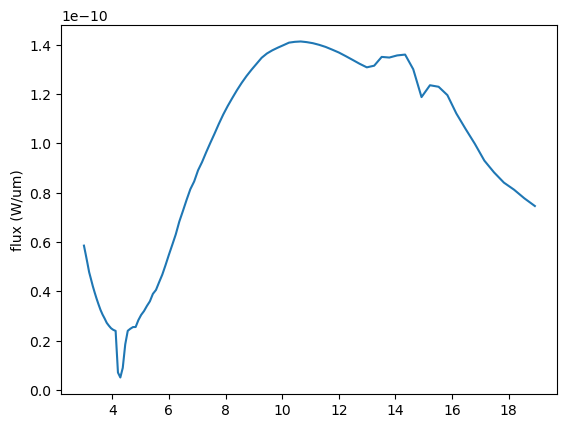

In [9]:
plt.plot(df['wavel'], df['flux_planet'])
#plt.yscale('log')
#plt.ylabel('flux (ph/m2/um/s)')#
plt.ylabel('flux (W/um)')
plt.show()  

In [ ]:
plt.

In [8]:
print(flux_given.unit)
print(A_tel.unit)
print(del_lambda.unit)
print(flux_nu.unit)

ph / s
m2
micron
ph / (micron s m2)


In [7]:
flux_nu

<Quantity [6.45632e+07, 6.20592e+07, 6.05775e+07, 5.80985e+07, 5.71991e+07,
           5.58689e+07, 5.45703e+07, 5.31170e+07, 5.16518e+07, 5.00164e+07,
           4.89144e+07, 4.81211e+07, 4.65377e+07, 4.63527e+07, 4.58476e+07,
           4.62128e+07, 4.69188e+07, 5.21012e+06, 1.94949e+04, 5.94747e+05,
           3.04263e+07, 5.40444e+07, 5.77170e+07, 5.91754e+07, 5.46651e+07,
           6.92885e+07, 7.94983e+07, 8.21071e+07, 8.82567e+07, 8.66912e+07,
           1.03048e+08, 7.51901e+07, 7.37160e+07, 4.66336e+07, 4.18506e+07,
           3.14063e+07, 1.04171e+08, 1.43143e+08, 4.89551e+07, 9.37233e+07,
           1.18470e+08, 1.77039e+08, 3.20428e+08, 3.56462e+08, 4.21849e+08,
           4.85652e+08, 5.40077e+08, 5.93595e+08, 6.33592e+08, 6.78123e+08,
           7.33700e+08, 7.93418e+08, 8.48030e+08, 9.03993e+08, 9.61319e+08,
           1.01999e+09, 1.07705e+09, 1.12353e+09, 1.18719e+09, 1.25790e+09,
           1.32651e+09, 1.38899e+09, 1.44046e+09, 1.50755e+09, 1.57200e+09,
           1

In [ ]:
# convert to F_lambda
flux_lambda = flux_nu * (const.c / wavel**2)
flux_lambda = flux_lambda.to(u.W / (u.m**2 * u.micron))

flux_photons = flux_lambda * (wavel / (const.h * const.c)) * u.ph
flux_photons = flux_photons.to(u.ph / (u.micron * u.s * u.m**2))

# incident flux from PSG spectrum
flux_psg_incident = np.interp(x = wavelength, 
                                xp = wavel, 
                                fp = flux_photons)

print('!!!------- FLUX CONVERSION FROM PSG FILE BEING DONE INCORRECTLY; CORRECT LATER -------!!!') ## ## TODO


## ## TODO: MAKE SURE SCALING, UNITS ARE RIGHT
# get BB spectrum for making a rough rescaling of the PSG spectrum

flux_bb_incident = self._calculate_flux_from_spectrum(source_name="exoplanet_bb", wavelength=wavelength, null=False)
#flux_incident_junk = self._calculate_flux_from_spectrum(source_name="exoplanet_model_10pc", wavelength=wavelength, null=False)

# integrate the BB spectrum over the wavelength grid
flux_incident_bb_integrated = np.trapz(y=flux_bb_incident, x=wavelength)

# integrate the PSG spectrum over the wavelength grid
flux_incident_psg_integrated = np.trapz(y=flux_psg_incident, x=wavelength)

# rescale the PSG spectrum to the BB spectrum
ratio_incident_psg_over_bb = (flux_incident_psg_integrated / flux_incident_bb_integrated).value

flux_incident = flux_psg_incident / ratio_incident_psg_over_bb